In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv


In [2]:
# IMPORT DEPENDENCIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os
os.listdir("/kaggle/input/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

['dirty_cafe_sales.csv']

## LOAD DATASET AND QUALITY REPORT

In [4]:
# LOAD DATASET
df = pd.read_csv("/kaggle/input/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv"
)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
# CHECK DATA TYPE AND NOT-NULL COUNT
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


From the above we can clearly see,data-type of 4 columns i.e, Quantity,Price per Unit,Total Spend,Transaction Date are object which is incorrect.

In [6]:
# DATASET QUALITY CHECK 
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


1. Transaction ID are all unique,there is no duplicate transaction id.
2. There are 10 unique items in cafe,total 5 payment method,location 4 and almost a year's sales.
3. Most frequently ordered quantity is 5, most common item bought is Juice,common payment is Digital and transaction are takeaway.
4.The most common transaction date is "UNKNOWN", indicating placeholder values that should be treated as missing data during preprocessing. 

## HANDLE MISSING VALUES

In [7]:
# TOTAL MISSING VALUES
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [8]:
# PERCENT OF DATA MISSING
df.isnull().sum()/len(df)*100

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [9]:
# Number of rows and columns
df.shape

(10000, 8)

## CHECK DUPLICATE ROWS

In [10]:
# CHECK HOW MANY DUPLICATE ROWS
df[df.duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


To check duplicate rows i used duplicated(). Here, it is seen there is no duplicate rows and all transactions are unique.

In [11]:
# Handling Misiing Data
df.replace('UNKNOWN',np.nan,inplace=True)
df.isnull().sum()

Transaction ID         0
Item                 677
Quantity             309
Price Per Unit       343
Total Spent          338
Payment Method      2872
Location            3603
Transaction Date     318
dtype: int64

The Transaction date has earlier UNKNOWN values which are  replaced by NaN so we can see Transaction Date missing values have increased( Earlier-159 and now-318)

## IMPUTATION

In [12]:
# IMPUTE ITEM WITH MODE
# FROM PREV. CELLS WE GOT MOST FREQUENT ORDERED ITEM IS "JUICE" = MODE
df["Item"] = df["Item"].replace(["UNKNOWN", "Error", "ERROR"], np.nan)
df["Item"] = df["Item"].fillna("Juice")

In [13]:
#check if missing values from item is replaced by mode(juice)
df['Item'].isnull().sum()

np.int64(0)

In [14]:
#IMPUTE QUANTITY WITH MEDIAN
# Convert Quantity to numeric
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
# Calculate median
median_q = df["Quantity"].median()
# Fill missing values
df["Quantity"] = df["Quantity"].fillna(median_q)
# Check missing values
df["Quantity"].isnull().sum()

np.int64(0)

In [15]:
#IMPUTE PRICE per Unit with median
#Convert Price per Unit to numeric
df['Price Per Unit']=pd.to_numeric(df['Price Per Unit'],errors='coerce')
#Calculate median
median_p = df['Price Per Unit'].median()
# Fill missing values
df["Price Per Unit"] = df["Price Per Unit"].fillna(median_p)
# Check missing values
df["Price Per Unit"].isnull().sum()

np.int64(0)

In [16]:
#IMPUTE PAYMENT METHOD WITH MODE
# FROM ABOVE WE SAW MODE OF PAYMENT METHOD WAS "Digital Wallet"
# Fill missing values
df["Payment Method"] = df["Payment Method"].replace(["UNKNOWN", "Error", "ERROR"], np.nan)
df["Payment Method"] = df["Payment Method"].fillna('Digital Wallet')
# Check missing values
df["Payment Method"].isnull().sum()

np.int64(0)

In [17]:
#IMPUTE LOCATION WITH MODE
mode_location = df["Location"].mode()[0]
# Fill missing values
df["Location"] = df["Location"].replace(["UNKNOWN", "Error", "ERROR"], np.nan)
df["Location"] = df["Location"].fillna('Takeaway')
# Check missing values
df["Location"].isnull().sum()

np.int64(0)

In [18]:
# Replace invalid values with NaN
df["Total Spent"] = df["Total Spent"].replace(["ERROR", "Error", "UNKNOWN"], np.nan)
# Convert to numeric
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
# Fill missing values with median
median = df["Total Spent"].median()
df["Total Spent"] = df["Total Spent"].fillna(median)
# Check data type
print(df["Total Spent"].dtype)

float64


## STANDARTIZATION

In [19]:
# BEFORE
print(df["Payment Method"].unique())
print(df["Location"].unique())
print(df["Item"].unique())

['Credit Card' 'Cash' 'Digital Wallet']
['Takeaway' 'In-store']
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Juice' 'Sandwich' 'Tea']


In [20]:
df['Payment Method'] = df['Payment Method'].str.strip().str.title()
df['Location'] = df['Location'].str.strip().str.title()
df['Item'] = df['Item'].str.strip().str.title()

In [21]:
#AFTER
print(df["Payment Method"].unique())
print(df["Location"].unique())
print(df["Item"].unique())

['Credit Card' 'Cash' 'Digital Wallet']
['Takeaway' 'In-Store']
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Juice' 'Sandwich' 'Tea']


The categorical columns (Item, Payment Method, and Location) were inspected for inconsistent formatting. No differences in capitalization or extra whitespace were found.

## OUTLIERS IN QUANTITY

In [22]:
Q1=np.percentile(df['Quantity'],25)
Q2=np.percentile(df['Quantity'],50)
Q3=np.percentile(df['Quantity'],75)
IQR=Q3-Q1
print("IQR:",IQR)

IQR: 2.0


In [23]:
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -1.0
Upper Bound: 7.0


In [24]:
outliers = df[(df["Quantity"] < lower_bound) | (df["Quantity"] > upper_bound)]
print("Number of outliers:", len(outliers))
outliers

Number of outliers: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


THERE IS NO OUTLIERS IN QUANTITY.

## OUTLIERS IN PRICE PER UNIT

In [25]:
Q1=np.percentile(df['Price Per Unit'],25)
Q2=np.percentile(df['Price Per Unit'],50)
Q3=np.percentile(df['Price Per Unit'],75)
IQR=Q3-Q1
print("IQR:",IQR)

IQR: 2.0


In [26]:
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -1.0
Upper Bound: 7.0


In [27]:
outliers = df[(df["Price Per Unit"] < lower_bound) | (df["Price Per Unit"] > upper_bound)]
print("Number of outliers:", len(outliers))
outliers

Number of outliers: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


There is no outlier in Price per Unit.

## OUTLIER IN TOTAL SPENT


In [28]:
Q1=np.percentile(df['Total Spent'],25)
Q2=np.percentile(df['Total Spent'],50)
Q3=np.percentile(df['Total Spent'],75)
IQR=Q3-Q1
print("IQR:",IQR)

IQR: 8.0


In [29]:
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -8.0
Upper Bound: 24.0


In [30]:
outliers = df[(df["Total Spent"] < lower_bound) | (df["Total Spent"] > upper_bound)]
print("Number of outliers:", len(outliers))
outliers

Number of outliers: 259


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
51,TXN_6342161,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-08
52,TXN_8914892,Juice,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-03-15
96,TXN_5220895,Salad,5.0,5.0,25.0,Cash,In-Store,2023-06-10
100,TXN_9517146,Juice,5.0,5.0,25.0,Cash,Takeaway,2023-10-30
...,...,...,...,...,...,...,...,...
9791,TXN_1232346,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-01-04
9805,TXN_9506076,Salad,5.0,5.0,25.0,Digital Wallet,Takeaway,2023-01-17
9879,TXN_6393305,Salad,5.0,5.0,25.0,Digital Wallet,In-Store,2023-10-19
9908,TXN_8922585,Salad,5.0,5.0,25.0,Credit Card,Takeaway,2023-06-22


A total of 259 outliers  were identified in the Total Spend column. After reviewing these records, the values appeared to represent legitimate high-value cafe transactions rather than data entry errors. Therefore, the outliers were retained in the cleaned dataset.


Although Quantity and Price Per Unit did not contain outliers, the derived column Total Spend showed 259 outliers using the IQR method. Since Total Spend is calculated from the product of Quantity and Price Per Unit, larger combinations naturally produce higher values. These records were reviewed and found to represent valid high-value transactions rather than data entry errors, so they were retained.

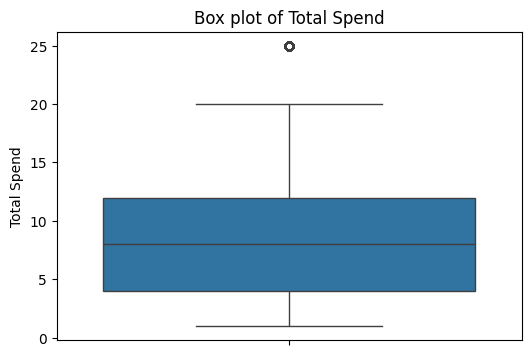

In [31]:
#visualize
import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Total Spent"])
plt.title("Box plot of Total Spend")
plt.ylabel("Total Spend")
plt.show()

## SAVE THE CLEANED DATA INTO CSV FILE

In [32]:
df.to_csv("cleaned_cafe_sales.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
